# Week 3 workshop · From PDE to pattern

> **Route through the workshop:** Specify → test one operator → initialise → update once → simulate → refine → measure morphology → compare parameters

## Workshop focus

The lecture and Reader use Gray–Scott to study reaction–diffusion and the move from particles to fields to a numerical grid. Here the correct baseline model is provided so that you can interrogate it by:

- translating its equations into an explicit numerical update;
- checking the discrete Laplacian on cases with known answers;
- separating reaction, diffusion, initialisation, and visualisation;
- checking whether a conclusion survives refinement;
- comparing patterns across parameters with observables that match the question.

The emphasis is on using code to understand and challenge the model, not reproducing the lecture figures or writing boilerplate from scratch.

> **Notation in this workshop.** The slides and Reader use lowercase $u$ and $v$ for individual particle species, then uppercase $U$ and $V$ for concentration fields. It is conventional to name concentration arrays `u` and `v`. In this workshop those lowercase code variables store **concentrations**, not individual particles.


# From the lecture to the workshop

The lecture moved up the ladder from random walks to continuous concentration fields, then down to values on a numerical grid. The workshop starts at that grid representation and asks whether the implementation preserves the behaviour we intended.

We will first isolate the discrete Laplacian and check that it smooths a field in the way diffusion should. Only then will we use the supplied reaction, feed, and removal terms.

**Canonical model used here:** Gray–Scott reaction–diffusion.

This notebook needs Python 3.10 or later, NumPy, Matplotlib, and IPython. It does not need the lecture repository or any separate data or image files. Run the cells in order from a fresh kernel before beginning an extension.


# The model we are implementing

The species are named $U$ and $V$. Their concentration fields are $u(x,y,t)$ and $v(x,y,t)$:

$$
\frac{\partial u}{\partial t}
=D_u\nabla^2u-uv^2+f(1-u),
$$

$$
\frac{\partial v}{\partial t}
=D_v\nabla^2v+uv^2-(f+k)v.
$$

| Term | Interpretation |
|---|---|
| $D_u\nabla^2u$, $D_v\nabla^2v$ | spatial diffusion |
| $uv^2$ | $U+2V\rightarrow3V$ converts $U$ into $V$ |
| $f(1-u)$ | replenishes $U$ towards concentration one |
| $(f+k)v$ | removes $V$ through feed dilution and the additional removal rate $k$ |

> **Modelling choice:** We will use a square grid, periodic boundaries, a five-point stencil, and explicit Euler time stepping. These are numerical choices, not properties of the chemistry.


## What goes into this model?

> **Discuss:** Which quantities are states, parameters, initial conditions, and numerical choices?

| Ingredient | Workshop choice |
|---|---|
| State | Two concentration fields, $u$ and $v$ |
| World | An $80\times80$ square lattice |
| Boundary | Periodic: the top joins the bottom and the left joins the right |
| Spatial operator | Five-point discrete Laplacian |
| Time integration | Explicit Euler |
| Initial condition | Nearly uniform state plus a local perturbation |
| Control parameters | Feed $f$ and kill $k$ |
| Observables | Spatial variance and orientation anisotropy of $v$ |

The lattice and timestep are parts of the numerical representation, not properties of the chemistry itself.


In [1]:
from dataclasses import dataclass
from typing import Sequence

import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

N = 80
DX = 1.0
DT = 1.0
DU = 0.16
DV = 0.08
FEED = 0.035
KILL = 0.060
SEED = 3024

INK = "#1B2A4C"
print(f"NumPy {np.__version__} · seed {SEED}")


NumPy 2.4.2 · seed 3024


# Discretise one operator

With grid spacing $\Delta x$, the five-point periodic Laplacian is

$$
(\nabla^2u)_{ij}\approx
\frac{u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1}-4u_{ij}}{\Delta x^2}.
$$

`np.roll` implements the wrap-around implied by periodic boundaries.

> **The ladder of abstraction:** **Down the ladder:** test the spatial operator before embedding it in a simulation.


In [2]:
def laplacian_periodic(field: np.ndarray, dx: float = 1.0) -> np.ndarray:
    """Return the five-point Laplacian of a 2D field with periodic boundaries."""
    field = np.asarray(field, dtype=float)
    if field.ndim != 2:
        raise ValueError("field must be a two-dimensional array")
    if dx <= 0:
        raise ValueError("dx must be positive")
    neighbours = (
        np.roll(field, 1, axis=0)
        + np.roll(field, -1, axis=0)
        + np.roll(field, 1, axis=1)
        + np.roll(field, -1, axis=1)
    )
    return (neighbours - 4.0 * field) / dx**2


## Test cases with known answers

Before running the next cell, predict:

1. What is the Laplacian of a constant field?
2. For a single central spike, what values appear at the centre and its four neighbours?
3. Why should the sum of a periodic discrete Laplacian be zero?


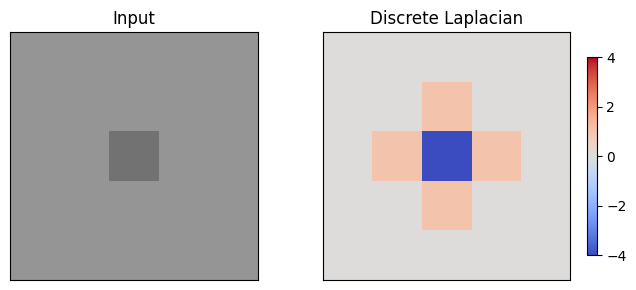

All Laplacian tests passed.


In [3]:
constant = np.ones((5, 5))
assert np.allclose(laplacian_periodic(constant), 0.0)

impulse = np.zeros((5, 5))
impulse[2, 2] = 1.0
impulse_laplacian = laplacian_periodic(impulse)
assert impulse_laplacian[2, 2] == -4.0
assert np.all(impulse_laplacian[[1, 2, 2, 3], [2, 1, 3, 2]] == 1.0)
assert np.isclose(impulse_laplacian.sum(), 0.0)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(impulse, cmap="Greys", vmin=-4, vmax=4)
axes[0].set_title("Input")
image = axes[1].imshow(impulse_laplacian, cmap="coolwarm", vmin=-4, vmax=4)
axes[1].set_title("Discrete Laplacian")
for ax in axes:
    ax.set(xticks=[], yticks=[])
fig.colorbar(image, ax=axes[1], shrink=0.8)
fig.tight_layout()
plt.show()
print("All Laplacian tests passed.")


# Initialise the state

The homogeneous state $u=1$, $v=0$ contains no visible structure. Pattern formation needs a perturbation. We place a small square of $B$ near the centre and add reproducible low-amplitude noise.

> **Discuss:** Why is the perturbation part of the experiment rather than harmless decoration?


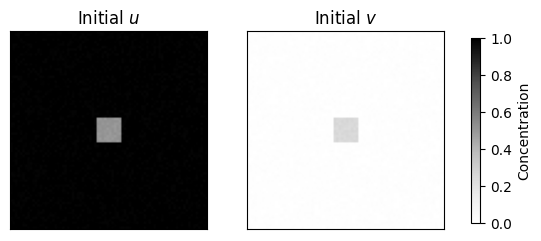

In [4]:
def initialise_gray_scott(
    n: int,
    rng: np.random.Generator,
    perturbation_size: int = 10,
    noise: float = 0.02,
) -> tuple[np.ndarray, np.ndarray]:
    """Return reproducible Gray–Scott concentration fields."""
    if n < 8:
        raise ValueError("n must be at least eight")
    if not 1 <= perturbation_size < n:
        raise ValueError("perturbation_size must lie between one and n-1")
    if noise < 0:
        raise ValueError("noise must be non-negative")

    u = np.ones((n, n), dtype=float)
    v = np.zeros((n, n), dtype=float)
    half = perturbation_size // 2
    centre = n // 2
    region = np.s_[centre - half : centre + half, centre - half : centre + half]
    u[region] = 0.50
    v[region] = 0.25
    if noise:
        u += rng.uniform(-noise, noise, size=u.shape)
        v += rng.uniform(-noise, noise, size=v.shape)
    return np.clip(u, 0, 1), np.clip(v, 0, 1)


rng = np.random.default_rng(SEED)
u0, v0 = initialise_gray_scott(N, rng)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, field, label in zip(axes, (u0, v0), ("$u$", "$v$")):
    image = ax.imshow(field, cmap="Greys", vmin=0, vmax=1)
    ax.set(title=f"Initial {label}", xticks=[], yticks=[])
fig.colorbar(image, ax=axes, shrink=0.8, label="Concentration")
plt.show()


# Apply one numerical update

Explicit Euler replaces $\partial u/\partial t$ with a finite change over $\Delta t$:

$$u^{n+1}=u^n+\Delta t\left[D_u\nabla^2u^n-u^n(v^n)^2+f(1-u^n)\right],$$

with the analogous update for $v$.

The function below does not mutate its inputs. This makes “before” and “after” states trustworthy and makes the update easier to test.


In [5]:
def gray_scott_step(
    u: np.ndarray,
    v: np.ndarray,
    *,
    du: float,
    dv: float,
    feed: float,
    kill: float,
    dt: float,
    dx: float = 1.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Advance the Gray–Scott system by one explicit Euler step."""
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    if u.shape != v.shape or u.ndim != 2:
        raise ValueError("u and v must be two-dimensional arrays with equal shape")
    if min(du, dv, feed, kill) < 0 or dt <= 0:
        raise ValueError("diffusion, feed, and kill must be non-negative; dt must be positive")

    reaction = u * v**2
    du_dt = du * laplacian_periodic(u, dx) - reaction + feed * (1.0 - u)
    dv_dt = dv * laplacian_periodic(v, dx) + reaction - (feed + kill) * v
    return u + dt * du_dt, v + dt * dv_dt


u0_before, v0_before = u0.copy(), v0.copy()
u1, v1 = gray_scott_step(
    u0, v0, du=DU, dv=DV, feed=FEED, kill=KILL, dt=DT, dx=DX
)
assert np.array_equal(u0, u0_before)
assert np.array_equal(v0, v0_before)
print(f"largest |Δu|: {np.max(np.abs(u1-u0)):.4f}")
print(f"largest |Δv|: {np.max(np.abs(v1-v0)):.4f}")


largest |Δu|: 0.1478
largest |Δv|: 0.0341


## Check the numerical scale

For diffusion alone in two dimensions, with equal grid spacing in both directions, the five-point explicit Euler scheme requires

$$\max(D_u,D_v)\frac{\Delta t}{\Delta x^2}\leq\frac14.$$

This is a necessary diffusion stability check, not a guarantee that the reaction terms or every nonlinear parameter choice are safe.


In [6]:
diffusion_number = max(DU, DV) * DT / DX**2
print(f"diffusion number = {diffusion_number:.3f}")
print("passes diffusion check" if diffusion_number <= 0.25 else "reduce DT")
assert diffusion_number <= 0.25


diffusion number = 0.160
passes diffusion check


# Iterate and record evidence

We save selected frames rather than every state. This keeps the output responsive while retaining enough history to inspect when structure appears.


In [7]:
@dataclass(frozen=True)
class GrayScottResult:
    times: np.ndarray
    v_frames: tuple[np.ndarray, ...]
    mean_v: np.ndarray
    variance_v: np.ndarray
    final_u: np.ndarray
    final_v: np.ndarray


def run_gray_scott(
    u_initial: np.ndarray,
    v_initial: np.ndarray,
    *,
    du: float = DU,
    dv: float = DV,
    feed: float = FEED,
    kill: float = KILL,
    dt: float = DT,
    dx: float = DX,
    steps: int = 2000,
    record_every: int = 100,
) -> GrayScottResult:
    """Simulate without mutating the supplied initial fields."""
    if steps < 1 or record_every < 1:
        raise ValueError("steps and record_every must be positive")
    if max(du, dv) * dt / dx**2 > 0.25:
        raise ValueError("explicit diffusion step is unstable: reduce dt or increase dx")

    u, v = u_initial.copy(), v_initial.copy()
    times, frames = [0], [v.copy()]
    means, variances = [float(v.mean())], [float(v.var())]

    for step in range(1, steps + 1):
        u, v = gray_scott_step(
            u, v, du=du, dv=dv, feed=feed, kill=kill, dt=dt, dx=dx
        )
        if not np.all(np.isfinite(u)) or not np.all(np.isfinite(v)):
            raise FloatingPointError(f"non-finite concentration at step {step}")
        if step % record_every == 0 or step == steps:
            times.append(step * dt)
            frames.append(v.copy())
            means.append(float(v.mean()))
            variances.append(float(v.var()))

    return GrayScottResult(
        times=np.asarray(times),
        v_frames=tuple(frames),
        mean_v=np.asarray(means),
        variance_v=np.asarray(variances),
        final_u=u,
        final_v=v,
    )


result = run_gray_scott(u0, v0)
print(f"recorded {len(result.v_frames)} frames through t={result.times[-1]:.0f}")
print(f"final u range: [{result.final_u.min():.3f}, {result.final_u.max():.3f}]")
print(f"final v range: [{result.final_v.min():.3f}, {result.final_v.max():.3f}]")


recorded 21 frames through t=2000
final u range: [0.281, 0.994]
final v range: [0.000, 0.370]


# Check refinement before interpreting the pattern

The timestep is part of the numerical representation. Halve $\Delta t$, double the number of steps, and compare at the same physical time.

If the two fields differ substantially, the apparent pattern may be a timestep artefact rather than a reliable consequence of the model.

> **Down the ladder:** challenge one numerical choice before moving up to system-level comparisons.


same physical time: t = 1200
field RMSE after halving dt: 0.00088


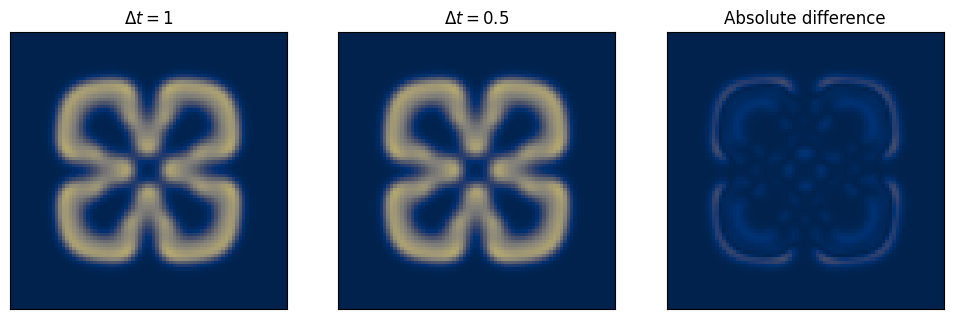

In [8]:
baseline_short = run_gray_scott(
    u0, v0, dt=1.0, steps=1200, record_every=100
)
refined_short = run_gray_scott(
    u0, v0, dt=0.5, steps=2400, record_every=200
)

refinement_rmse = float(
    np.sqrt(np.mean((baseline_short.final_v - refined_short.final_v) ** 2))
)
print(f"same physical time: t = {baseline_short.times[-1]:.0f}")
print(f"field RMSE after halving dt: {refinement_rmse:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
views = (
    (baseline_short.final_v, "$\\Delta t=1$"),
    (refined_short.final_v, "$\\Delta t=0.5$"),
    (np.abs(baseline_short.final_v-refined_short.final_v), "Absolute difference"),
)
for ax, (field, title) in zip(axes, views):
    vmax = 0.5 if "difference" not in title.lower() else max(0.02, field.max())
    ax.imshow(field, cmap="cividis", vmin=0, vmax=vmax)
    ax.set(title=title, xticks=[], yticks=[])
fig.tight_layout()
plt.show()


Discuss whether the difference is small enough for the question being asked. There is no universal tolerance: a qualitative claim about spots may survive an error that would invalidate a precise wavelength estimate.


## Pause the process

Use the slider or play button to locate the first unmistakable spatial structure. The colour scale remains fixed so apparent change reflects the state, not automatic rescaling.


In [9]:
def field_player(
    frames: Sequence[np.ndarray],
    times: Sequence[float],
    element_id: str = "gray-scott-player",
) -> HTML:
    """Return a dependency-free canvas player for 2D scalar fields."""
    data = json.dumps([np.round(frame, 4).tolist() for frame in frames])
    time_data = json.dumps([float(t) for t in times])
    return HTML(f"""
    <div id="{element_id}" style="max-width:600px;font-family:Arial,sans-serif;color:#1B2A4C">
      <canvas width="480" height="480" style="width:min(100%,480px);image-rendering:pixelated;border:1px solid #C7CEDC"></canvas>
      <div style="display:flex;gap:12px;align-items:center;margin-top:8px">
        <button type="button">Play</button>
        <input type="range" min="0" max="{len(frames)-1}" value="0" style="flex:1;accent-color:#1B2A4C">
        <span></span>
      </div>
    </div>
    <script>
    (() => {{
      const root=document.getElementById('{element_id}'), frames={data}, times={time_data};
      const canvas=root.querySelector('canvas'), ctx=canvas.getContext('2d');
      const slider=root.querySelector('input'), button=root.querySelector('button'), label=root.querySelector('span');
      let timer=null;
      function colour(value) {{
        const q=Math.max(0,Math.min(1,value/0.5));
        const r=Math.round(255+(27-255)*q), g=Math.round(255+(42-255)*q), b=Math.round(255+(76-255)*q);
        return `rgb(${{r}},${{g}},${{b}})`;
      }}
      function draw(k) {{
        const frame=frames[k], h=frame.length, w=frame[0].length, cw=canvas.width/w, ch=canvas.height/h;
        frame.forEach((row,i)=>row.forEach((value,j)=>{{ctx.fillStyle=colour(value);ctx.fillRect(j*cw,i*ch,cw+.5,ch+.5);}}));
        label.textContent=`t = ${{times[k]}}`;
      }}
      function stop() {{clearInterval(timer);timer=null;button.textContent='Play';}}
      button.onclick=()=>{{if(timer){{stop();return;}}button.textContent='Pause';timer=setInterval(()=>{{let k=+slider.value;if(k>=frames.length-1){{stop();return;}}slider.value=k+1;draw(k+1);}},300);}};
      slider.oninput=()=>draw(+slider.value); draw(0);
    }})();
    </script>
    """)


display(field_player(result.v_frames, result.times))


# Two views of the same run

The field is a qualitative representation. Spatial variance compresses that field to one number:

$$\operatorname{Var}(v)=\frac{1}{N^2}\sum_{ij}(v_{ij}-\bar v)^2.$$

Variance detects spatial contrast, but it cannot distinguish spots from stripes or many small patches from a few large ones. We therefore add a simple orientation statistic.

> **The ladder of abstraction:** **Up the ladder:** compress a concentration field into system-level observables.


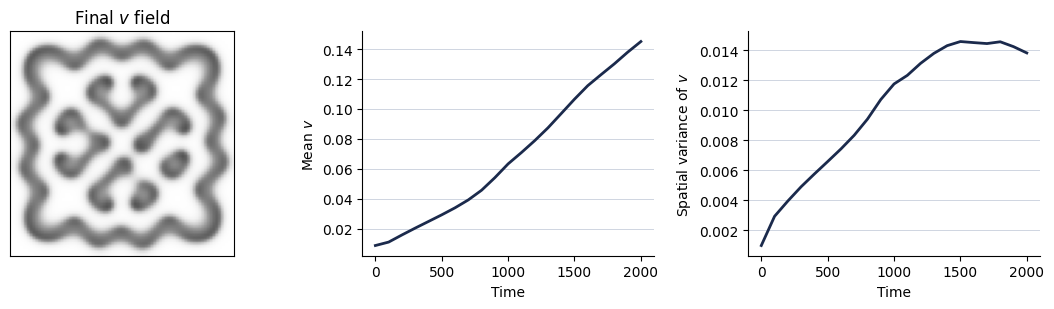

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].imshow(result.final_v, cmap="Greys", vmin=0, vmax=0.5)
axes[0].set(title="Final $v$ field", xticks=[], yticks=[])
axes[1].plot(result.times, result.mean_v, color=INK, linewidth=2)
axes[1].set(xlabel="Time", ylabel="Mean $v$")
axes[2].plot(result.times, result.variance_v, color=INK, linewidth=2)
axes[2].set(xlabel="Time", ylabel="Spatial variance of $v$")
for ax in axes[1:]:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#C7CEDC", linewidth=0.6)
fig.tight_layout()
plt.show()


## Add one morphology-aware observable

Let $E_x$ and $E_y$ be the mean squared changes across horizontal and vertical neighbours. Define

$$
A=\frac{|E_x-E_y|}{E_x+E_y}.
$$

$A$ is near zero when the field has no preferred axis and larger for strongly aligned stripes. It is not a complete morphology measure, but it answers a question variance cannot.


In [11]:
def orientation_anisotropy(field: np.ndarray) -> float:
    """Return axial gradient anisotropy in [0, 1]."""
    field = np.asarray(field, dtype=float)
    dx_energy = float(np.mean(np.diff(field, axis=1) ** 2))
    dy_energy = float(np.mean(np.diff(field, axis=0) ** 2))
    total = dx_energy + dy_energy
    return 0.0 if np.isclose(total, 0.0) else abs(dx_energy-dy_energy)/total

vertical_stripes = np.tile(np.arange(20) % 2, (20, 1))
horizontal_stripes = vertical_stripes.T
uniform_field = np.ones((20, 20))
assert orientation_anisotropy(vertical_stripes) > 0.95
assert orientation_anisotropy(horizontal_stripes) > 0.95
assert orientation_anisotropy(uniform_field) == 0.0

print(f"final Var(v): {result.variance_v[-1]:.5f}")
print(f"final orientation anisotropy: {orientation_anisotropy(result.final_v):.3f}")


final Var(v): 0.01382
final orientation anisotropy: 0.005


> **Discuss:** Can two visibly different patterns have the same variance? What additional observable would distinguish them?

Possible further observables include a spatial correlation length, radial power spectrum, or the number and size of connected regions. Each retains different information.


# Vary one meaningful choice

Hold the initial condition and numerical settings fixed while varying feed and kill. This isolates the parameter change from stochastic differences in initialisation.

> **Discuss:** Predict how spatial contrast and directional organisation will change across the three parameter pairs.


   baseline: Var(v)=0.01312, anisotropy=0.001
 lower kill: Var(v)=0.01025, anisotropy=0.000
higher feed: Var(v)=0.01796, anisotropy=0.002


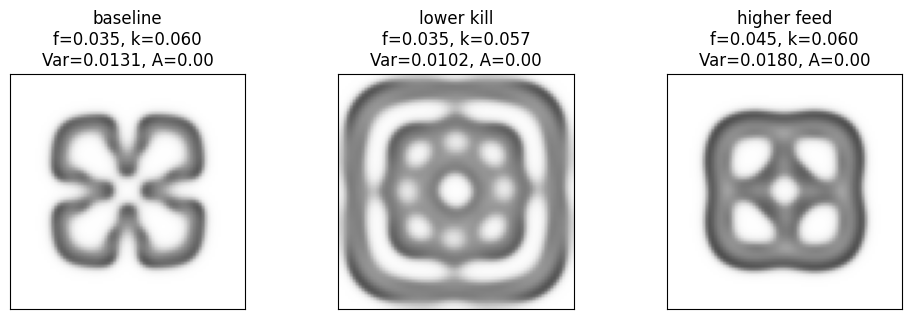

In [12]:
parameter_sets = {
    "baseline": (0.035, 0.060),
    "lower kill": (0.035, 0.057),
    "higher feed": (0.045, 0.060),
}

comparisons = {}
for label, (feed, kill) in parameter_sets.items():
    comparisons[label] = run_gray_scott(
        u0, v0, feed=feed, kill=kill, steps=1200, record_every=100
    )

for label, run in comparisons.items():
    print(
        f"{label:>11}: Var(v)={run.variance_v[-1]:.5f}, "
        f"anisotropy={orientation_anisotropy(run.final_v):.3f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
for ax, (label, run) in zip(axes, comparisons.items()):
    ax.imshow(run.final_v, cmap="Greys", vmin=0, vmax=0.5)
    ax.set_title(
        f"{label}\nf={parameter_sets[label][0]:.3f}, k={parameter_sets[label][1]:.3f}\n"
        f"Var={run.variance_v[-1]:.4f}, A={orientation_anisotropy(run.final_v):.2f}"
    )
    ax.set(xticks=[], yticks=[])
fig.tight_layout()
plt.show()


# Further investigation

There is no universally best feed or kill rate. A preferred parameter pair exists only after specifying a pattern, biological question, or quantitative objective.

First interpret the comparison already produced:

1. Which visual differences are captured by variance?
2. Which are invisible to it?
3. Did the refinement check support interpreting these differences?
4. Which aspects are chemistry, and which depend on the numerical representation?

Then choose one extension. Record a prediction and preserve the tested baseline.

- **Challenge a boundary choice:** implement no-flux boundaries and test the boundary operator before simulating.
- **Challenge an observable:** implement an observable that distinguishes spots from stripes and test it on constructed fields first.
- **Challenge the diffusion ratio:** compare $D_U=D_V$ with several unequal pairs while holding the reaction parameters and initial state fixed. Track both morphology and whether perturbations grow. Unequal diffusion is necessary for a classical two-species Turing instability, but it is not sufficient, and Gray–Scott can also produce patterns through other nonlinear mechanisms.
- **Challenge the initial condition:** vary perturbation geometry or noise amplitude while holding model parameters fixed.

In [ ]:
# Your extension goes here. Preserve the baseline functions where possible.


# Exit ticket

In four sentences:

1. State one change of representation used this week.
2. State one numerical choice.
3. Describe what the morphology-aware observable retained and discarded.
4. Explain how the refinement check changed your confidence in the result.

> **The ladder of abstraction:** PDE → discrete operator → local update → concentration field → system-level observable.
